In [1]:
from utils import *
NOTEBOOK_ID = '04'

In [2]:
out_file = f'{EXPERIMENT_DIR}/magnetic_sorting_data.csv'
if os.path.isfile(out_file):
    data_df = None
    for data_file in glob(f'{EXPERIMENT_DIR}/magnets/*_compiled_data.csv'):
        id = data_file.split('/')[-1].replace('_compiled_data.csv','')
        tmp_df = pd.read_csv(data_file,index_col=0)
        tmp_df['dataset'] = id
        data_df = pd.concat([data_df,tmp_df]).reset_index(drop=True)
    large_lib = pd.read_csv(f'{LIBRARY_DIR}/eLW044-fLW132.csv')
    mapper = dict(zip(large_lib['library_ID'],large_lib['tile_ID']))
    data_df['tileID'] = data_df['tileID'].replace(mapper)
    seq_df = pd.concat([
        pd.read_csv(f'{TILE_DIR}/viral_tiles.csv'),
        pd.read_csv(f'{LIBRARY_DIR}/viral_controls.csv')])[['tile_ID','tile']]
    seq_df['tile'] = seq_df['tile'].apply(lambda x: x[:-1] + x[-1].replace('*',''))
    data_df = (data_df
               .rename(columns={'tileID':'tile_ID'})
               .merge(seq_df,on='tile_ID'))
    protein_df = pd.read_csv(f'{TILE_DIR}/viral_proteins_clustered90.csv')
    id_map = dict(zip(protein_df['protein_ID'],protein_df['accession']))
    data_df['protein_id'] = data_df['tile_ID'].apply(lambda x: '-'.join(x.split('-')[:-1]))
    data_df['ncbi_id'] = data_df['protein_id'].replace(id_map)

    genbank_accessions = list(data_df['ncbi_id'].unique())
    if not os.path.isfile(f'{ANALYSIS_DIR}/tax_ids.csv'):
        ncbi_ids = []
        for acc in tqdm(genbank_accessions):
            if 'NC' in acc:
                ncbi_ids.append(get_taxid_from_accession(acc))
        tax_ids = [taxid for taxid in ncbi_ids if taxid is not None]
        pd.DataFrame(tax_ids).to_csv(f'{ANALYSIS_DIR}/tax_ids.csv',index=False)

        tree = ncbi.get_topology(tax_ids)
        tree.write(format=1, outfile=f'{ANALYSIS_DIR}/taxonomical_tree.nwk')
    else:
        tax_ids = pd.read_csv(f'{ANALYSIS_DIR}/tax_ids.csv')["0"].to_list()

    tax_mapper = dict(zip(genbank_accessions,tax_ids))
    data_df['tax_id'] = data_df['ncbi_id'].map(tax_mapper)
    data_df.to_csv(out_file,index=False)
else:
    data_df = pd.read_csv(out_file)
data_df.head()

,tile_ID,ratio_rep1,coverage_rep1,ratio_rep2,coverage_rep2,iscontrol,log_cov_rep1,log_cov_rep2,dataset,ratio_rep3,coverage_rep3,log_cov_rep3,tile,protein_id,ncbi_id,tax_id
0,A1,0.759964,0.001345,0.697140,0.001065,yes,-2.871267,-2.972788,500,NaN,NaN,NaN,KKKGDGSGSGSGSGSVDLDLDLELRLGFALDLDLELRLGFALDLDL...,,,1770265.0
1,A1,0.678302,0.014918,0.636914,0.015860,yes,-1.826291,-1.799709,250,0.610058,0.015116,-1.820562,KKKGDGSGSGSGSGSVDLDLDLELRLGFALDLDLELRLGFALDLDL...,,,1770265.0
2,A1,0.420913,0.001232,0.558164,0.001573,yes,-2.909379,-2.803193,1K,NaN,NaN,NaN,KKKGDGSGSGSGSGSVDLDLDLELRLGFALDLDLELRLGFALDLDL...,,,1770265.0
3,A1,0.677157,0.000050,0.222862,0.000011,yes,-4.304599,-4.951321,2K,NaN,NaN,NaN,KKKGDGSGSGSGSGSVDLDLDLELRLGFALDLDLELRLGFALDLDL...,,,1770265.0
4,A6774_gp2-004,0.883110,0.003004,0.805959,0.002934,no,-2.522259,-2.532598,500,NaN,NaN,NaN,PAVGCSLSQGETSSSADLPQFCADFGYMPPDLDWSYVKTVQGVREQ...,A6774_gp2,NC_029993,1825924.0


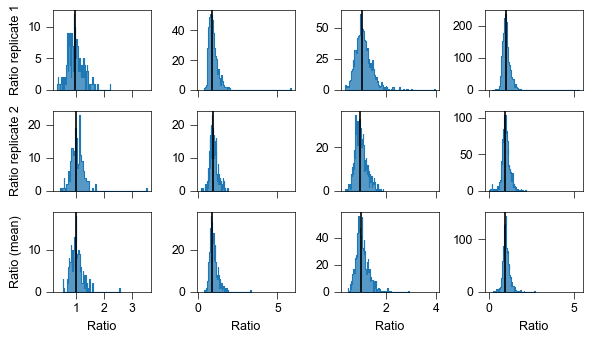

In [3]:
data_df['ratio_mean'] = data_df[['ratio_rep1','ratio_rep2']].mean(axis=1)
tmp_df = data_df.drop(columns=[
    'log_cov_rep1', 'log_cov_rep2', 'log_cov_rep3',
    'protein_id', 'ncbi_id', 'tax_id'
]).copy()

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(6, 3.5), sharex='col')

datasets = {
    "250": {"filter": None},
    "500": {"filter": "ratio_rep2 < 10"},
    "1K": {"filter": None},
    "2K": {"filter": None}
}

for col_idx, (dataset, settings) in enumerate(datasets.items()):
    query = f'dataset == "{dataset}"'
    if settings["filter"]:
        query += f' and {settings["filter"]}'
    subset = tmp_df.query(query).copy()

    for row_idx, ratio in enumerate(['ratio_rep1', 'ratio_rep2', 'ratio_mean']):
        ax = axes[row_idx, col_idx]
        g = sns.histplot(data=subset, x=ratio, ax=ax, bins=100, element='step')
        g.axvline(x=subset[ratio].median(), ymin=0, ymax=200, color='black')
        
        if col_idx == 0:
            ylabel = {
                0: 'Ratio replicate 1',
                1: 'Ratio replicate 2',
                2: 'Ratio (mean)'
            }[row_idx]
            ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel(None)
        
        if row_idx == 2:
            ax.set_xlabel('Ratio')

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-ratio_histograms.svg',**FIG_PARAMS)

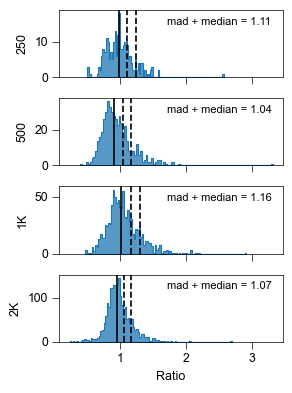

In [4]:
mad_df = (
    tmp_df.query('ratio_rep2 < 10')
    .groupby('dataset')['ratio_mean']
    .apply(calculate_mad)
    .reset_index()
    .loc[[1, 3, 0, 2]]  # reorder datasets
    .rename(columns={'ratio_mean': 'mad'})
)
mad_dict = dict(zip(mad_df['dataset'], mad_df['mad']))

tmp_df = data_df.drop(columns=[
    'log_cov_rep1', 'log_cov_rep2', 'log_cov_rep3', 
    'protein_id', 'ncbi_id', 'tax_id'
]).copy()

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(3, 4), sharex=True)

datasets = {
    "250": None,
    "500": "ratio_rep2 < 10",
    "1K": None,
    "2K": None
}

for ax, (dataset, filter_condition) in zip(axes, datasets.items()):
    query = f'dataset == "{dataset}"'
    if filter_condition:
        query += f' and {filter_condition}'
    subset = tmp_df.query(query).copy()
    
    median_val = subset['ratio_mean'].median()
    mad_val = mad_dict[dataset]

    g = sns.histplot(data=subset, x='ratio_mean', ax=ax, bins=100, element='step')
    g.axvline(x=median_val, ymin=0, ymax=200, color='black')
    g.axvline(x=median_val + mad_val, ymin=0, ymax=200, color='black', linestyle='--')
    g.axvline(x=median_val + mad_val * 2, ymin=0, ymax=200, color='black', linestyle='--')

    ax.set_ylabel(dataset)
    ax.set_xlabel('Ratio')

    ax.text(2.5, ax.get_ylim()[1] * 0.9, f"mad + median = {median_val + mad_val:.2f}",
            ha='center', va='top', fontsize=8)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-ratio_histograms_mad.svg',**FIG_PARAMS)